# The Visual Storyteller — Exploratory Data Analysis

**Notebook 0 of the project** (run this first). Explores the Flickr8k caption dataset and *justifies the key modelling hyperparameters* with real numbers.

Contents:
0. Setup & data load
1. Dataset overview (image / caption counts)
2. Caption length distribution → justifies `max_caption_len = 22`
3. Vocabulary: frequency, Zipf, `<unk>` rate (train-only)
4. Coverage vs `min_word_freq` → justifies `min_word_freq = 3`
5. Top words & bigrams (stopword dominance, domain skew)
6. Sample images with their 5 captions
7. Image properties → justifies the `Resize(256) → CenterCrop(224)` transform
8. Split sanity & leakage check
9. Caption quality & diversity

> All data utilities are imported from `src/`; the notebook never re-implements cleaning, vocab, or splits. Every statistic that feeds a modelling decision is computed on **train ids only** (no val/test leakage). Clear outputs before committing.

## 0. Setup & data load

Loads captions through the same `src.data` code path the trainer uses, and picks the same seeded splits, so every number here is the number the model actually sees. Works locally (`./data` or the unzipped `./caption_data`) and on Colab.

In [1]:
import os, sys, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

REPO = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if REPO not in sys.path:
    sys.path.insert(0, REPO)

from src.config import default_config, SPECIAL_TOKENS
from src.data import (load_captions, build_vocab, make_splits,
                      load_official_splits, references_for)

# Colab -> Drive paths; locally fall back to ./data or the unzipped ./caption_data
try:
    import google.colab  # noqa: F401
    cfg = default_config(); cfg.use_colab_paths()
except ImportError:
    cfg = default_config()
if not os.path.exists(cfg.captions_file):
    alt = os.path.join(REPO, 'caption_data')
    if os.path.exists(os.path.join(alt, 'captions.txt')):
        cfg.data_dir = alt
        cfg.captions_file = os.path.join(alt, 'captions.txt')
        cfg.images_dir = os.path.join(alt, 'Images')

DATA_READY = os.path.exists(cfg.captions_file)
print('captions:', cfg.captions_file, '->', 'found' if DATA_READY else 'NOT FOUND')
print('images  :', cfg.images_dir, '->', 'found' if os.path.isdir(cfg.images_dir) else 'NOT FOUND')

if DATA_READY:
    caps = load_captions(cfg.captions_file)
    splits = load_official_splits(cfg.data_dir) or make_splits(sorted(caps), sizes=(6000, 1000, 1000), seed=cfg.seed)
    train, val, test = splits['train'], splits['val'], splits['test']
    print(f"\nimages: {len(caps)} | captions: {sum(len(v) for v in caps.values())}")
    print(f"splits -> train {len(train)} | val {len(val)} | test {len(test)}")
    print(f"knobs under test -> min_word_freq={cfg.min_word_freq}  max_caption_len={cfg.max_caption_len}")
else:
    caps, splits, train, val, test = {}, {}, [], [], []
    print('\n[notice] dataset not found — see README (Data setup). Cells below will be skipped.')

captions: /Users/andria/Desktop/deep_learning/final project/visual_story_teller/caption_data/captions.txt -> found
images  : /Users/andria/Desktop/deep_learning/final project/visual_story_teller/caption_data/Images -> found

images: 8091 | captions: 40455
splits -> train 6000 | val 1000 | test 1000
knobs under test -> min_word_freq=3  max_caption_len=22


## 1. Dataset overview

Confirms the **5-captions-per-image** structure that the evaluation relies on (each image is decoded once and scored against all 5 references). If cleaning had emptied some captions, an image with <5 refs would show up here before it could quietly skew BLEU. The dataset size (~30k caption–image pairs) is also *why* we freeze the ResNet-50 encoder — it's far too little data to fine-tune 25M vision parameters.

captions-per-image value counts:
5    8091


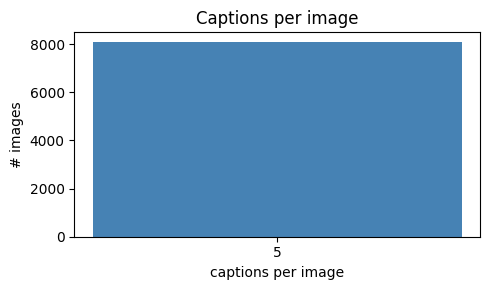


                metric    value
                images   8091.0
              captions  40455.0
   mean captions/image      5.0
total tokens (cleaned) 436795.0


In [2]:
if DATA_READY:
    n_images = len(caps)
    n_caps = sum(len(v) for v in caps.values())
    per_image = pd.Series({k: len(v) for k, v in caps.items()})
    print('captions-per-image value counts:')
    print(per_image.value_counts().sort_index().to_string())

    vc = per_image.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(vc.index.astype(str), vc.values, color='steelblue')
    ax.set_xlabel('captions per image'); ax.set_ylabel('# images'); ax.set_title('Captions per image')
    plt.tight_layout(); plt.show()

    total_tokens = sum(len(t) for v in caps.values() for t in v)
    summary = pd.DataFrame({'metric': ['images', 'captions', 'mean captions/image', 'total tokens (cleaned)'],
                            'value':  [n_images, n_caps, round(n_caps / n_images, 2), total_tokens]})
    print('\n' + summary.to_string(index=False))
else:
    print('skipped — no data')

## 2. Caption length distribution → justifies `max_caption_len = 22`

Lengths are **cleaned token counts**, excluding `<start>`/`<end>`. `CaptionDataset` truncates each token list to `max_caption_len` *before* adding the two special tokens, so this is the directly relevant comparison. The cap bounds the Transformer's positional table and the LSTM's unrolled steps; the histogram shows what fraction of captions the cutoff actually touches.

length (cleaned tokens): min 1 | max 36 | mean 10.80 | median 10 | std 3.76
percentiles  p50=10  p90=16  p95=18  p99=22
captions longer than max_caption_len=22: 289 (0.71%) -> truncated


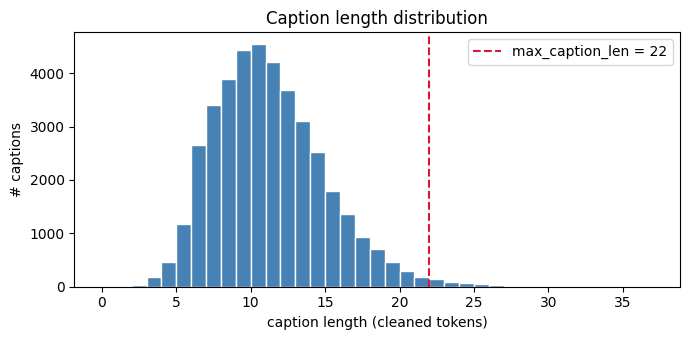

In [3]:
if DATA_READY:
    lengths = np.array([len(t) for v in caps.values() for t in v])
    p = np.percentile(lengths, [50, 90, 95, 99])
    print(f"length (cleaned tokens): min {lengths.min()} | max {lengths.max()} | "
          f"mean {lengths.mean():.2f} | median {np.median(lengths):.0f} | std {lengths.std():.2f}")
    print(f"percentiles  p50={p[0]:.0f}  p90={p[1]:.0f}  p95={p[2]:.0f}  p99={p[3]:.0f}")
    cap = cfg.max_caption_len
    over = int((lengths > cap).sum())
    print(f"captions longer than max_caption_len={cap}: {over} ({over/len(lengths):.2%}) -> truncated")

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(lengths, bins=range(0, int(lengths.max()) + 2), color='steelblue', edgecolor='white')
    ax.axvline(cap, color='crimson', linestyle='--', label=f'max_caption_len = {cap}')
    ax.set_xlabel('caption length (cleaned tokens)'); ax.set_ylabel('# captions')
    ax.set_title('Caption length distribution'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('skipped — no data')

## 3. Vocabulary: frequency, Zipf & `<unk>` rate (train only)

Word counts here come from **training captions only** — the same thing `build_vocab(..., image_ids=train)` does. The Zipf log-log line shows the long tail that motivates an `<unk>` token at all. The number that actually matters is the **val/test `<unk>` rate**: the fraction of reference tokens the model can never produce because they're out of vocabulary. Computing it with a train-built vocab is the concrete, leakage-free version of the "build vocab from train only" rule.

train types: 7397 | train tokens: 323884
hapax (freq==1): 2908 (39.3% of types) -- the long tail


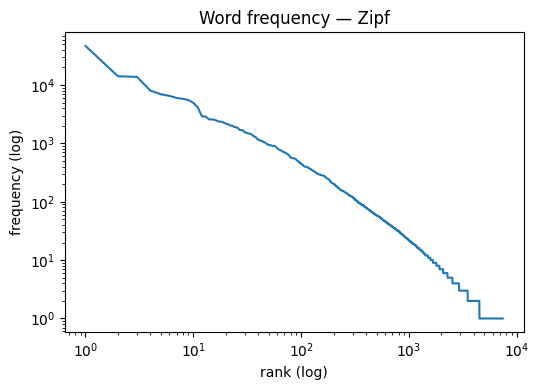


vocab size (train-only, min_freq=3): 3497
<unk> token rate -> train 1.51% | val 2.25% | test 2.40%


In [4]:
if DATA_READY:
    train_counter = Counter()
    for img in train:
        for toks in caps[img]:
            train_counter.update(toks)
    train_tokens = sum(train_counter.values())
    hapax = sum(1 for c in train_counter.values() if c == 1)
    print(f"train types: {len(train_counter)} | train tokens: {train_tokens}")
    print(f"hapax (freq==1): {hapax} ({hapax/len(train_counter):.1%} of types) -- the long tail")

    freqs = np.array(sorted(train_counter.values(), reverse=True))
    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.loglog(np.arange(1, len(freqs) + 1), freqs)
    ax.set_xlabel('rank (log)'); ax.set_ylabel('frequency (log)'); ax.set_title('Word frequency — Zipf')
    plt.tight_layout(); plt.show()

    vocab = build_vocab(caps, min_freq=cfg.min_word_freq, image_ids=set(train))
    known = set(vocab.stoi)
    def oov_rate(ids):
        toks = [w for img in ids for t in caps[img] for w in t]
        return (sum(1 for w in toks if w not in known) / len(toks)) if toks else 0.0
    tr_oov = sum(c for w, c in train_counter.items() if c < cfg.min_word_freq) / train_tokens
    print(f"\nvocab size (train-only, min_freq={cfg.min_word_freq}): {len(vocab)}")
    print(f"<unk> token rate -> train {tr_oov:.2%} | val {oov_rate(val):.2%} | test {oov_rate(test):.2%}")
else:
    train_counter, train_tokens = Counter(), 0
    print('skipped — no data')

## 4. Coverage vs `min_word_freq` → justifies lowering 5 → 3

This is the **decision plot** for the `min_word_freq = 3` change (down from 5). Sweeping the threshold over the prebuilt train counter, we trade vocabulary size (= softmax / embedding parameters) against token coverage and the val/test `<unk>` rate. It lets the report state precisely how coverage and vocabulary size move as the threshold changes, and why 3 is a better operating point than 5 for this data.

 min_freq  vocab_size  train_cov%  val_unk%  test_unk%
        1        7401      100.00      1.12       1.23
        2        4493       99.10      1.74       1.87
        3        3497       98.49      2.25       2.40
        4        2915       97.95      2.73       2.84
        5        2526       97.47      3.14       3.25
        8        1917       96.37      4.16       4.23
       10        1668       95.71      4.77       4.81


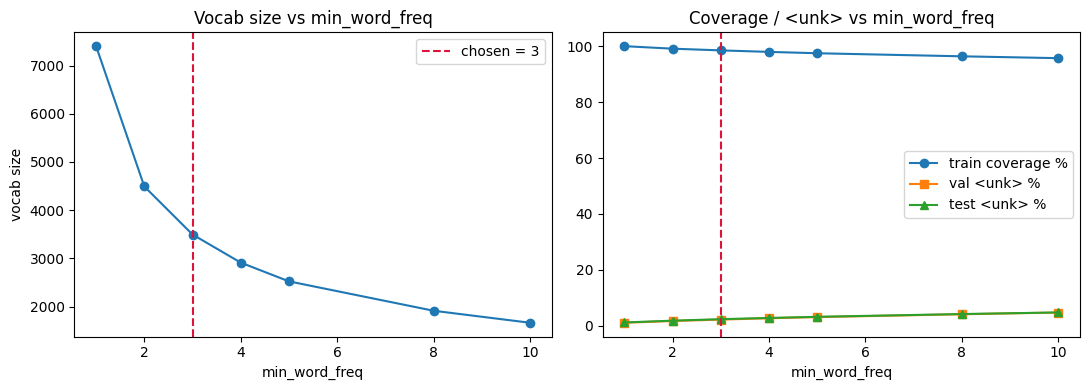

In [5]:
if DATA_READY:
    val_toks = [w for img in val for t in caps[img] for w in t]
    test_toks = [w for img in test for t in caps[img] for w in t]
    rows = []
    for mf in [1, 2, 3, 4, 5, 8, 10]:
        keep = {w for w, c in train_counter.items() if c >= mf}
        vsize = len(SPECIAL_TOKENS) + len(keep)
        train_cov = sum(c for w, c in train_counter.items() if c >= mf) / train_tokens
        v_unk = sum(1 for w in val_toks if w not in keep) / max(len(val_toks), 1)
        te_unk = sum(1 for w in test_toks if w not in keep) / max(len(test_toks), 1)
        rows.append([mf, vsize, round(train_cov * 100, 2), round(v_unk * 100, 2), round(te_unk * 100, 2)])
    cov = pd.DataFrame(rows, columns=['min_freq', 'vocab_size', 'train_cov%', 'val_unk%', 'test_unk%'])
    print(cov.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(cov['min_freq'], cov['vocab_size'], 'o-')
    axes[0].axvline(cfg.min_word_freq, color='crimson', linestyle='--', label=f'chosen = {cfg.min_word_freq}')
    axes[0].set_title('Vocab size vs min_word_freq'); axes[0].set_xlabel('min_word_freq'); axes[0].set_ylabel('vocab size'); axes[0].legend()
    axes[1].plot(cov['min_freq'], cov['train_cov%'], 'o-', label='train coverage %')
    axes[1].plot(cov['min_freq'], cov['val_unk%'], 's-', label='val <unk> %')
    axes[1].plot(cov['min_freq'], cov['test_unk%'], '^-', label='test <unk> %')
    axes[1].axvline(cfg.min_word_freq, color='crimson', linestyle='--')
    axes[1].set_title('Coverage / <unk> vs min_word_freq'); axes[1].set_xlabel('min_word_freq'); axes[1].legend()
    plt.tight_layout(); plt.show()
else:
    print('skipped — no data')

## 5. Top words & bigrams

Sets expectations for the metric and the qualitative review. A handful of function words dominate the head of the distribution, so **BLEU-1 looks deceptively high** from stopword overlap alone — which is why the project early-stops on BLEU-4. The leading content words (`dog`, `man`, `boy`, `water`…) reveal Flickr8k's people-and-animals domain skew, framing what failure cases to expect.

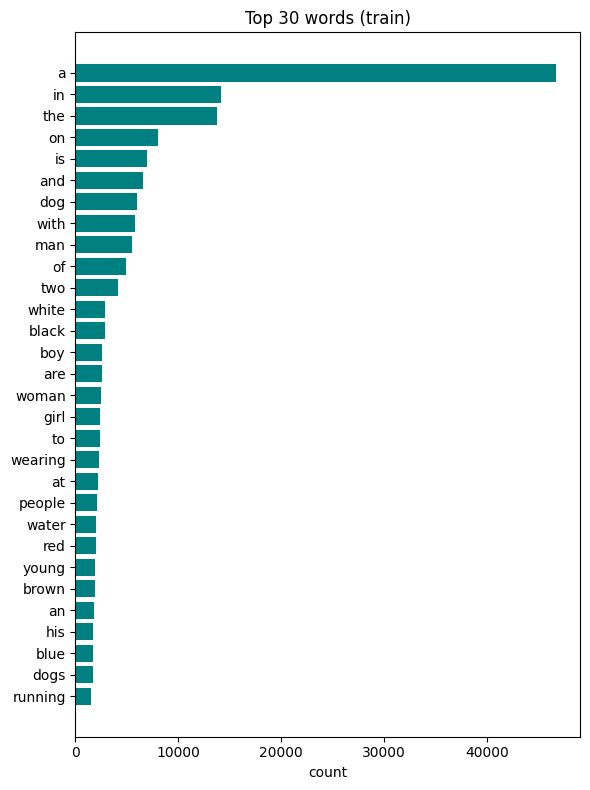

top-10 types cover 36.6% of all tokens | top-50 cover 57.9%

top 15 bigrams:
  in a              4854
  on a              3920
  a man            3842
  in the            3772
  with a              2452
  on the            1841
  of a              1781
  a woman          1611
  a dog            1504
  a black          1462
  dog is             1300
  wearing a              1248
  a young          1235
  man in             1189
  a red            1166


In [6]:
if DATA_READY:
    top = train_counter.most_common(30)
    words = [w for w, _ in top][::-1]; counts = [c for _, c in top][::-1]
    fig, ax = plt.subplots(figsize=(6, 8))
    ax.barh(words, counts, color='teal'); ax.set_title('Top 30 words (train)'); ax.set_xlabel('count')
    plt.tight_layout(); plt.show()

    cum = np.cumsum([c for _, c in train_counter.most_common()]) / train_tokens
    print(f"top-10 types cover {cum[9]:.1%} of all tokens | top-50 cover {cum[49]:.1%}")

    bigrams = Counter()
    for img in train:
        for t in caps[img]:
            bigrams.update(zip(t, t[1:]))
    print('\ntop 15 bigrams:')
    for (a, b), c in bigrams.most_common(15):
        print(f'  {a} {b:14s} {c}')
else:
    print('skipped — no data')

## 6. Sample images with their 5 captions

Grounds the statistics in what the data actually looks like. Seeing the spread across the 5 references for a single image is exactly *why* we score against all 5 (not one). Also a sanity check that the image filenames line up with the caption ids (the `.jpg`-keyed contract used by `features.h5`).

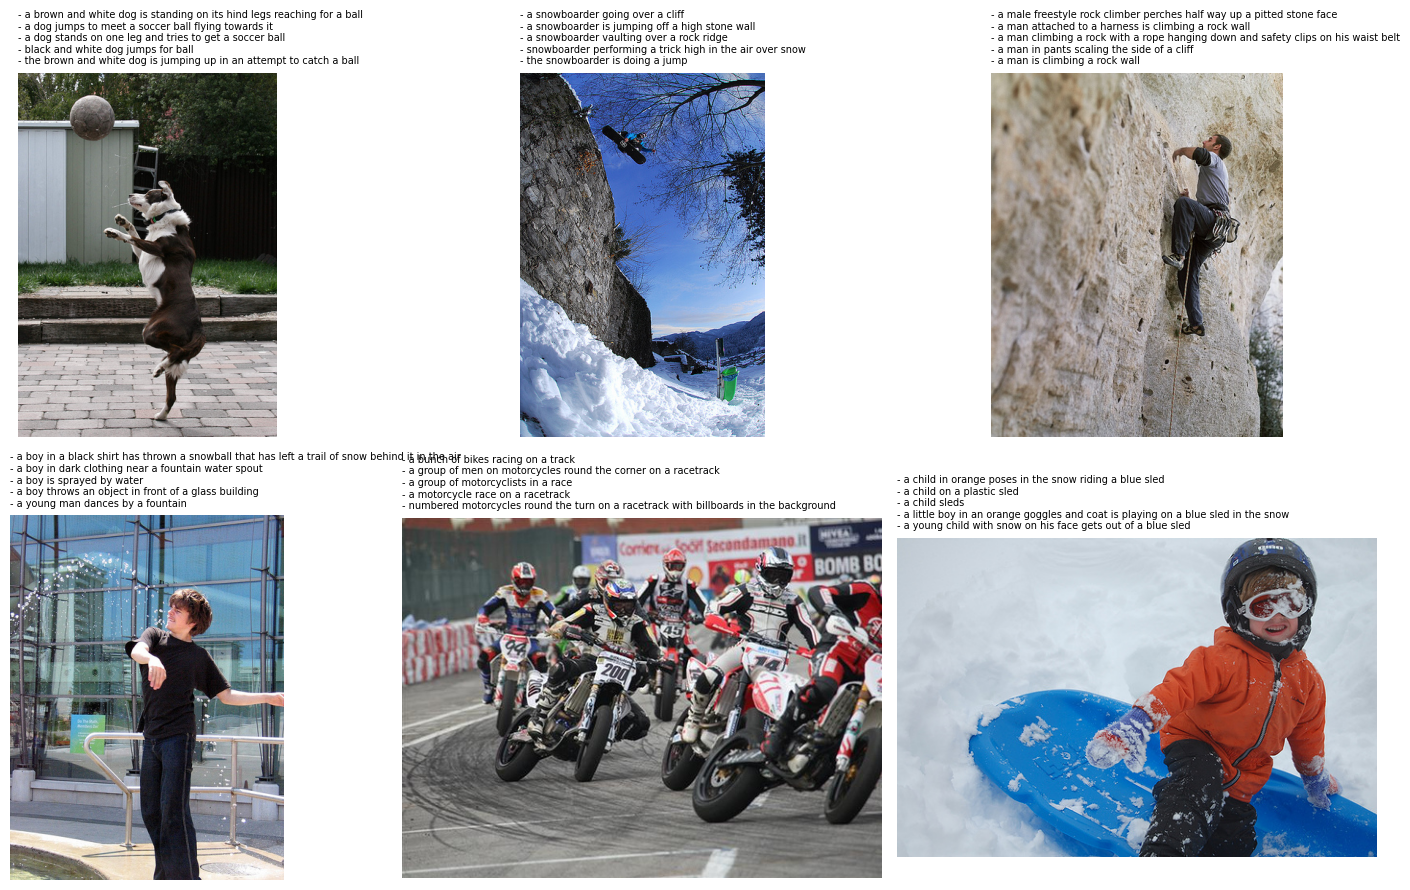

In [7]:
if DATA_READY and os.path.isdir(cfg.images_dir):
    ids = random.Random(cfg.seed).sample(train, 6)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, img in zip(axes.flat, ids):
        ax.imshow(Image.open(os.path.join(cfg.images_dir, img)).convert('RGB'))
        ax.axis('off')
        ax.set_title('\n'.join('- ' + ' '.join(t) for t in caps[img][:5]), fontsize=7, loc='left')
    plt.tight_layout(); plt.show()
else:
    print('skipped — images not available at', cfg.images_dir)

## 7. Image properties → the resize/crop choice

Flickr8k images are variable-size and mostly landscape (one side typically pinned to 500px). The frozen ResNet-50 expects 224×224, producing the 7×7×2048 = `num_regions=49`, `feature_dim=2048` grid both decoders attend over. With aspect ratios up to ~2.8, a `Resize(256) → CenterCrop(224)` would clip ~20% off each long-axis end on the more elongated third of images — which for captioning can crop out real objects (a failure that looks like decoder weakness but is really lost input).

**Decision (from this EDA):** `build_image_transform` now resizes directly to **224×224 (squash, no crop)** so no content is lost; the center-crop variant is kept as a commented A/B alternative in `encoder.py`.

sampled 400 images
width  min/mean/max: 202/459/500
height min/mean/max: 178/401/500
aspect ratio (w/h) min/mean/max: 0.40/1.21/2.81
landscape 68% | portrait 29% | square 2%


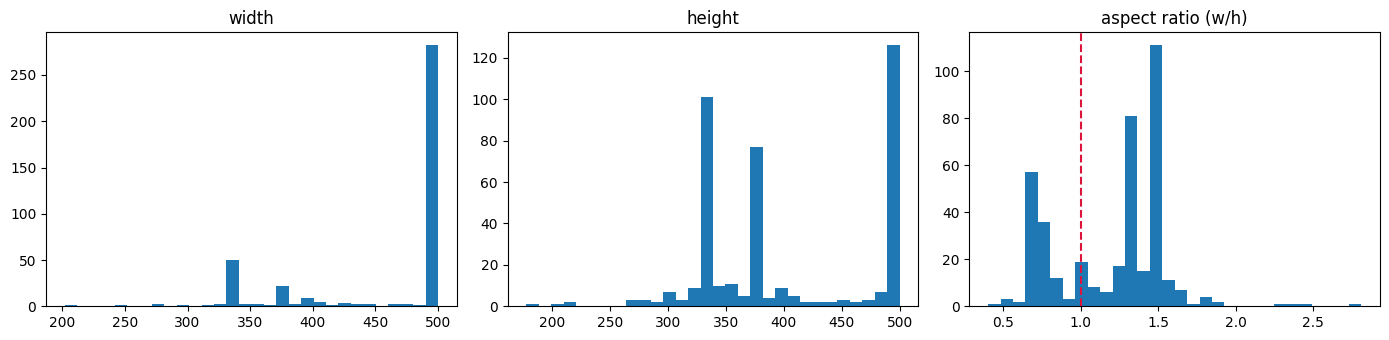

In [8]:
if DATA_READY and os.path.isdir(cfg.images_dir):
    files = [f for f in os.listdir(cfg.images_dir) if f.lower().endswith('.jpg')]
    sample = random.Random(cfg.seed).sample(files, min(400, len(files)))
    W, H = [], []
    for f in sample:
        with Image.open(os.path.join(cfg.images_dir, f)) as im:
            w, h = im.size
        W.append(w); H.append(h)
    W, H = np.array(W), np.array(H); AR = W / H
    print(f"sampled {len(sample)} images")
    print(f"width  min/mean/max: {W.min()}/{W.mean():.0f}/{W.max()}")
    print(f"height min/mean/max: {H.min()}/{H.mean():.0f}/{H.max()}")
    print(f"aspect ratio (w/h) min/mean/max: {AR.min():.2f}/{AR.mean():.2f}/{AR.max():.2f}")
    print(f"landscape {(AR>1).mean():.0%} | portrait {(AR<1).mean():.0%} | square {(AR==1).mean():.0%}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    axes[0].hist(W, bins=30); axes[0].set_title('width')
    axes[1].hist(H, bins=30); axes[1].set_title('height')
    axes[2].hist(AR, bins=30); axes[2].axvline(1.0, color='crimson', linestyle='--'); axes[2].set_title('aspect ratio (w/h)')
    plt.tight_layout(); plt.show()
else:
    print('skipped — images not available')

## 8. Split sanity & leakage check

The single most important correctness guard. Splits must be **image-disjoint** (not caption-disjoint) so the same picture never leaks across train/test, which would inflate BLEU. We assert zero overlap and confirm the vocabulary was built from train ids only. Comparable per-split length distributions justify that val is a fair early-stopping proxy for test.

In [9]:
if DATA_READY:
    used = len(train) + len(val) + len(test)
    print(f"split sizes -> train {len(train)} | val {len(val)} | test {len(test)} (using {used} of {len(caps)} images)")
    s_tr, s_va, s_te = set(train), set(val), set(test)
    print('overlaps -> train&val:', len(s_tr & s_va), '| train&test:', len(s_tr & s_te), '| val&test:', len(s_va & s_te))
    assert not (s_tr & s_va) and not (s_tr & s_te) and not (s_va & s_te), 'SPLIT LEAKAGE!'
    print('OK: no image overlap across splits; vocab is built from train ids only.')

    rows = [[name, len(ids), sum(len(caps[i]) for i in ids),
             round(float(np.mean([len(t) for i in ids for t in caps[i]])), 2)]
            for name, ids in [('train', train), ('val', val), ('test', test)]]
    print('\n' + pd.DataFrame(rows, columns=['split', 'images', 'captions', 'mean_len']).to_string(index=False))
else:
    print('skipped — no data')

split sizes -> train 6000 | val 1000 | test 1000 (using 8000 of 8091 images)
overlaps -> train&val: 0 | train&test: 0 | val&test: 0
OK: no image overlap across splits; vocab is built from train ids only.

split  images  captions  mean_len
train    6000     30000     10.80
  val    1000      5000     10.83
 test    1000      5000     10.77


## 9. Caption quality & diversity

Flags data-quality issues that shape interpretation. Low **distinct-2** means references are formulaic, so a model can post decent BLEU with generic captions — an important caveat for the write-up. Duplicate references within an image change the effective reference set. The dominant `a / two / man` openings explain why both decoders converge to similar first tokens and motivate beam search over greedy decoding.

**Decision (from this EDA):** the small (~30k pairs), formulaic dataset makes the larger from-scratch Transformer prone to overfitting, so its `dropout` was raised from 0.1 → 0.25 in `config.py`.

In [10]:
if DATA_READY:
    def diversity(ids):
        toks = [w for img in ids for t in caps[img] for w in t]
        uni = set(toks); bi = set(zip(toks, toks[1:]))
        return len(uni) / max(len(toks), 1), len(bi) / max(len(toks) - 1, 1)
    ttr, d2 = diversity(train)
    print(f"train type-token ratio: {ttr:.4f} | distinct-2: {d2:.4f}")

    dup_imgs = sum(1 for v in caps.values() if len({' '.join(t) for t in v}) < len(v))
    print(f"images with >=2 identical references: {dup_imgs} ({dup_imgs/len(caps):.1%})")

    starts = Counter(t[0] for v in caps.values() for t in v if t)
    tot = sum(starts.values())
    print('\nmost common opening words:')
    for w, c in starts.most_common(8):
        print(f'  {w:8s} {c} ({c/tot:.1%})')
else:
    print('skipped — no data')

train type-token ratio: 0.0228 | distinct-2: 0.1939
images with >=2 identical references: 19 (0.2%)

most common opening words:
  a        24704 (61.1%)
  two      4727 (11.7%)
  the      3121 (7.7%)
  three    1168 (2.9%)
  an       533 (1.3%)
  people   461 (1.1%)
  man      457 (1.1%)
  four     389 (1.0%)
